In [4]:
import pandas as pd
import numpy as np

In [ ]:
df_clean = pd.read_csv("../data/processed/HHS_Clean_Dataset.csv")
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean = df_clean.sort_values("Date")
df_clean = df_clean.set_index("Date")

series = df_clean["Children in HHS Care"]
train_size = int(len(series) * 0.8)
train = series[:train_size]
test = series[train_size:]

Date
Friday         2
Monday       142
Sunday       127
Thursday     145
Tuesday      146
Wednesday    144
Name: count, dtype: int64


In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:              Children in HHS Care   No. Observations:                  564
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -3481.734
Date:                           Wed, 05 Aug 2026   AIC                           6973.467
Time:                                   13:30:14   BIC                           6994.990
Sample:                                        0   HQIC                          6981.880
                                           - 564                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9368      0.025     36.993      0.000       0.887       0.986
ma.L1         -0.7825      0.047    -16.718

In [7]:
sarima_forecast = sarima_fit.forecast(steps=len(test))
sarima_forecast.index = test.index

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

mae = mean_absolute_error(test, sarima_forecast)
rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
mape = mean_absolute_percentage_error(test, sarima_forecast)

print("SARIMA MAE :", mae)
print("SARIMA RMSE:", rmse)
print("SARIMA MAPE:", mape * 100)

SARIMA MAE : 643.9922792307239
SARIMA RMSE: 870.7843898148097
SARIMA MAPE: 28.039218661417742


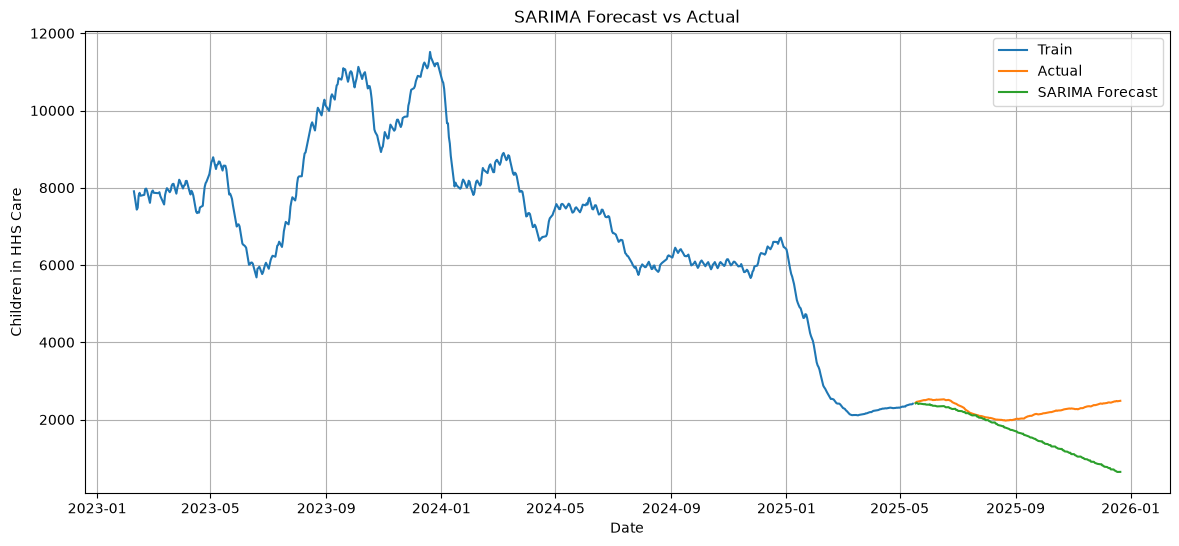

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(test))
sarima_forecast.index = test.index

# Metrics
mae = mean_absolute_error(test, sarima_forecast)
rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
mape = mean_absolute_percentage_error(test, sarima_forecast)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape*100:.2f}%")

MAE  : 643.99
RMSE : 870.78
MAPE : 28.04%


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


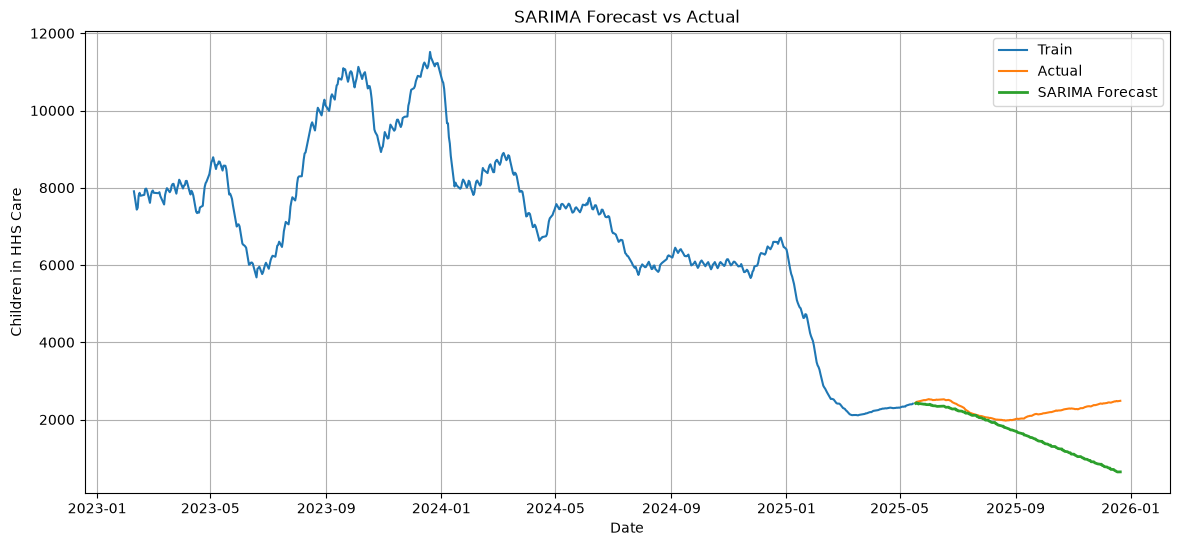

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast", linewidth=2)

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(True)
plt.show()